In [2]:
import sys, os
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']='.9'
import jax_cosmo.background as bkgrd
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"
from jax.lib import xla_bridge
# platform = xla_bridge.get_backend().platform
import jax
from jaxopt import ScipyBoundedMinimize
from jaxopt import LBFGSB
from jax import value_and_grad

print(jax.local_device_count(), jax.device_count())
# jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)
import jax
# Change the current working directory to the desired path
# os.chdir('/mnt/home/spandey/ceph/GODMAX/src/')

import matplotlib

import matplotlib.pyplot as pl
# set latex to false:
pl.rcParams['text.usetex'] = False
%load_ext autoreload
%autoreload 2
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)
# import numpyro
# numpyro.set_platform("gpu")
# numpyro.enable_x64()
from jax import config
config.update("jax_enable_x64", True)
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import copy
import jax.numpy as jnp
import colossus 
from jax import vmap, grad, pmap
import matplotlib.pyplot as pl
import jax_cosmo.background as bkgrd
import time
from jax_cosmo import Cosmology
from jax_cosmo.background import angular_diameter_distance, radial_comoving_distance
from astropy import constants as const
pl.rc('text', usetex=True)
# Palatino
# pl.rc('font', family='DejaVu Sans')

%matplotlib inline
%load_ext autoreload
%autoreload 2




1 1
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import yaml
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 

from deepmerge import always_merger
def read_yaml(file_path):
    with open(file_path, 'r') as file:
        data = yaml.safe_load(file)
    return data

def generate_dicts(data):
    sim_params_dict = data.get('sim_params', {})
    halo_params_dict = data.get('halo_params', {})
    analysis_dict = data.get('analysis', {})
    other_params_dict = data.get('other_params', {})
    return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict

default_data = read_yaml(abs_path_params + '/params_default.yaml')
new_data = read_yaml(abs_path_params + '/xCMASS/params_fit_test.yaml')
merged_data = always_merger.merge(default_data, new_data)

sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(merged_data)

from scipy.interpolate import interp1d
ks = np.geomspace(3e-1,10,10) # wavenumbers
zarray_lens = np.linspace(0.001, 1.6, 200)


cosmo_params = sim_params_dict.get('cosmo')
cosmo_jax = Cosmology(
            Omega_c=cosmo_params['Om0'] - cosmo_params['Ob0'],
            Omega_b=cosmo_params['Ob0'],
            h=cosmo_params['H0'] / 100.,
            sigma8=cosmo_params['sigma8'],
            n_s=cosmo_params['ns'],
            Omega_k=0.,
            w0=cosmo_params['w0'],
            wa=0.
            )
scale_fac_a_array = 1.0 / (1.0 + zarray_lens)

import asdf
# z_array = np.linspace(0, 1.5, 200)
# z_centers = 0.5 * (z_array[1:] + z_array[:-1])
zvals = [0.5]
nbins_lens = len(zvals)
# zarray_lens_edges = 
delta_zarray = zarray_lens[1] - zarray_lens[0]
zarray_lens_edges = np.concatenate(([zarray_lens[0] - delta_zarray/2], 0.5*(zarray_lens[1:] + zarray_lens[:-1]), [zarray_lens[-1] + delta_zarray/2]))
nz_comoving_all = np.zeros((len(zvals), len(zarray_lens)))
nz_lens = {}
nbar_all = []
Ngals_bins = []
for jz, zval in enumerate(zvals):
    df = pk.load(open(f"{abs_path_data}/CMASS/measure_cmass_planck.pk", 'rb'))
    
    zmin = df['zmin']
    zmax = df['zmax']
    chi_min = radial_comoving_distance(cosmo_jax, 1.0/(1.0 + zmin))
    chi_max = radial_comoving_distance(cosmo_jax, 1.0/(1.0 + zmax))

    comoving_volume = (4.0/3.0) * np.pi * (chi_max**3 - chi_min**3) * (1/8.)
    nbar = df['Ngal'] / comoving_volume  # in (Mpc/h)^-3
    nbar_all.append(nbar)

    zcen, nz_f = df['zcen'], df['nz']
    nz_f_norm = nz_f / (np.trapz(nz_f, zcen))
    nz_f_norm_interp = interp1d(zcen, nz_f_norm, fill_value=0.0, bounds_error=False)
    hist_z = nz_f_norm_interp(zarray_lens)
    nz_lens[jz] = hist_z

    nz_comoving = np.zeros_like(zarray_lens)
    indsel = np.where(hist_z > 1e-5)[0]
    nz_comoving[indsel] = nbar
    nz_comoving_all[jz] = nz_comoving

analysis_dict['nbar_gal_comoving_zarray'] = zarray_lens
analysis_dict['nbar_gal_comoving_val'] = np.sum(np.array(nz_comoving_all), axis=0)

nz_info_dict = {}
nz_info_dict['z_array_lens'] = zarray_lens
nz_info_dict['nbins_lens'] = nbins_lens
for ji in range(nz_info_dict['nbins_lens']):
    nz_info_dict['nz'+str(ji)] = np.maximum(nz_lens[ji], 1e-3)
analysis_dict['nz_lens_info_dict'] = nz_info_dict


analysis_dict['is_cmb_lensing'] = True
from astropy.io import fits
# df = fits.open(os.path.abspath(abs_path_data + '/forecast/lsst_simulate_Y1.fits'))
# z_array = df['nz_source'].data['Z_MID']
nz_info_dict = {}
nz_info_dict['z_array_source'] = jnp.ones(1)
nz_info_dict['nbins'] = 1
for ji in range(nz_info_dict['nbins']):
    nz_info_dict['nz'+str(ji)] = jnp.ones(1)
analysis_dict['nz_source_info_dict'] = nz_info_dict
other_params_dict['Delta_z_bias_array'] = jnp.zeros(analysis_dict['nz_source_info_dict']['nbins'])
other_params_dict['mult_shear_bias_array'] = jnp.zeros(analysis_dict['nz_source_info_dict']['nbins'])

# analysis_dict['angles_data_array'] = df['xip'].data['ANG'][0:20]

analysis_dict['k_array_survey'] = jnp.array(ks / (sim_params_dict['cosmo']['H0']/100.))

lmin, lmax, dl_log_array = 80.0, 8800.0, 0.23025851
l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
dl_array = l_array_all[1:] - l_array_all[:-1]
l_array_survey = (l_array_all[1:] + l_array_all[:-1]) / 2.
halo_params_dict['ell_array'] = jnp.array(l_array_survey)
analysis_dict['l_array_survey'] = jnp.array(l_array_survey)
analysis_dict['dl_array_survey'] = jnp.array(dl_array)

analysis_dict['symbolic_pk'] = True
analysis_dict['symbolic_hmf'] = True

# analysis_dict['symbolic_pk'] = False
# analysis_dict['symbolic_hmf'] = False




In [4]:
from base_class import base_class
from get_radial_profiles import Profiles
from get_Pkzs import get_Pkz
from get_Cls import get_Cl
from get_Xis import get_xi
from get_covs import get_cov
import matplotlib.pyplot as pl

base_test = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
profiles_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
Pkz_test = get_Pkz(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=profiles_test)
Cls_test = get_Cl(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Pkz_obj=Pkz_test)




(100, 3000.0)

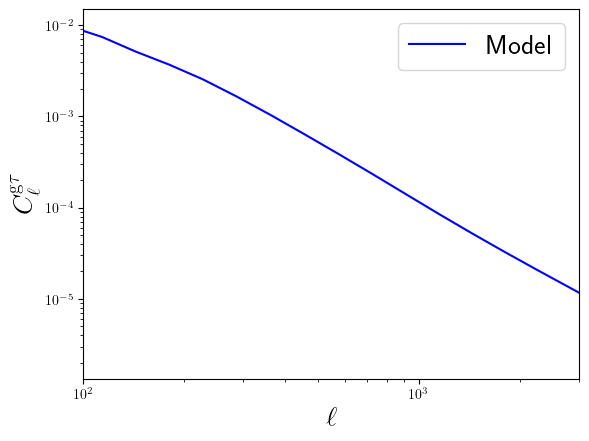

In [5]:
pl.figure
pl.plot(Cls_test.ell_array, Cls_test.Cl_gal_tau_tot_mat[:,0], color='blue', label=r'Model')
pl.xscale('log')
pl.yscale('log')
pl.xlabel(r'$\ell$', fontsize=20)
pl.ylabel(r'$C_\ell^{\mathrm{g \tau}}$', fontsize=20)
pl.legend(fontsize=20)
pl.xlim(100, 3e3)





(100, 3000.0)

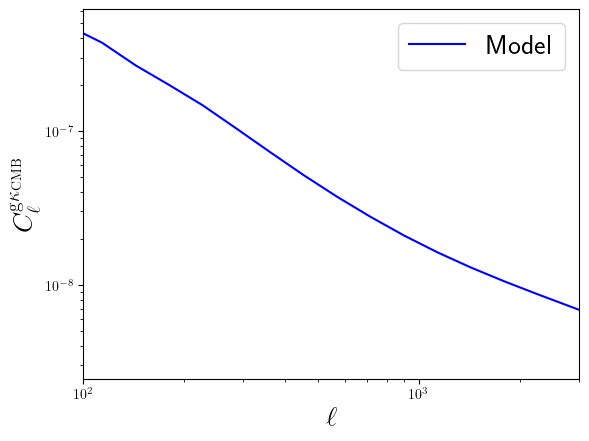

In [27]:
# arcmin_to_rad = (1.0/60.0) * (np.pi/180.0)
# nbar_inv_noise = 1/(analysis_dict['nbar_lens_bins'] / (arcmin_to_rad**2))
pl.figure
pl.plot(Cls_test.ell_array, Cls_test.Cl_gal_kappa_tot_mat[:,0,0], color='blue', label=r'Model')
# pl.errorbar(l_array_sims, Cl_gg_data, yerr=0.1*Cl_gg_data, fmt='o', color='k', label='Data', alpha=0.4)
pl.xscale('log')
pl.yscale('log')
pl.xlabel(r'$\ell$', fontsize=20)
pl.ylabel(r'$C_\ell^{\mathrm{g \kappa_{\rm CMB}}}$', fontsize=20)
pl.legend(fontsize=20)
pl.xlim(100, 3e3)





(100, 3000.0)

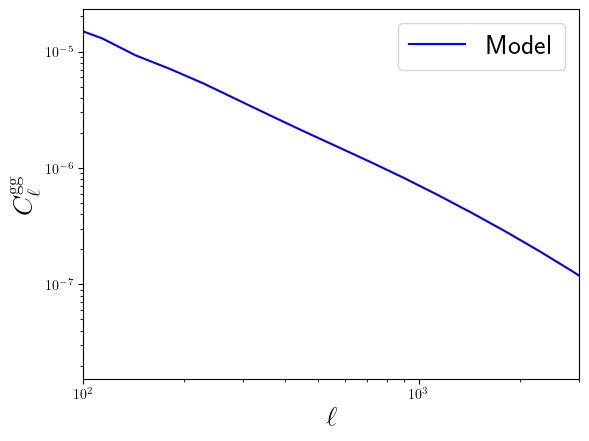

In [28]:
pl.figure
pl.plot(Cls_test.ell_array, Cls_test.Cl_gal_gal_tot_mat[:,0,0], color='blue', label=r'Model')
pl.xscale('log')
pl.yscale('log')
pl.xlabel(r'$\ell$', fontsize=20)
pl.ylabel(r'$C_\ell^{\mathrm{gg}}$', fontsize=20)
pl.legend(fontsize=20)
pl.xlim(100, 3e3)



(1e-15, 1e-11)

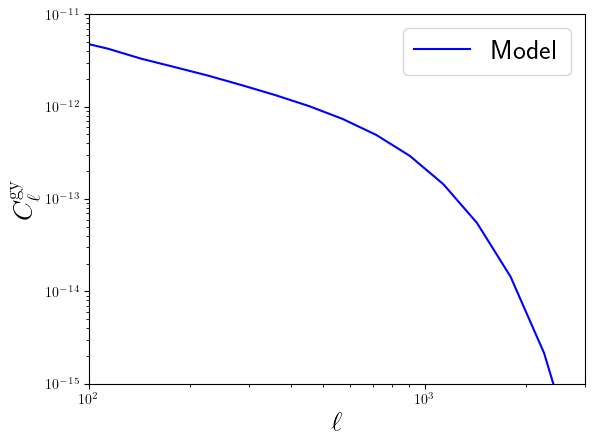

In [8]:
pl.figure
pl.plot(Cls_test.ell_array, Cls_test.Cl_gal_y_tot_mat[:,0], color='blue', label=r'Model')
pl.xscale('log')
pl.yscale('log')
pl.xlabel(r'$\ell$', fontsize=20)
pl.ylabel(r'$C_\ell^{\mathrm{gy}}$', fontsize=20)
pl.legend(fontsize=20)
pl.xlim(100, 3e3)
pl.ylim(1e-15, 1e-11)
